# ASL-DVS Viewer

This notebook loads a single ASL-DVS `.mat` file from `data/ASLDVS`, shows basic metadata, and renders a few simple visualizations.

The raw `.mat` files store sensor coordinates. This notebook flips the vertical axis to match the orientation that `tonic.datasets.ASLDVS` uses, so the handshape looks the way you would expect in a normal image.

Use the `CLASS_NAME` and `SAMPLE_INDEX` values below to switch to a different letter/sample and rerun the notebook cells.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy.io import loadmat

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["image.cmap"] = "coolwarm"

SENSOR_HEIGHT = 180
SENSOR_WIDTH = 240


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "ASLDVS").exists():
            return candidate
    raise FileNotFoundError("Could not find data/ASLDVS from the current working directory.")


def flip_y_for_display(raw_y: np.ndarray) -> np.ndarray:
    return SENSOR_HEIGHT - 1 - raw_y.astype(np.int64)


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_ROOT = PROJECT_ROOT / "data" / "ASLDVS"

PROJECT_ROOT, DATA_ROOT

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
CLASS_NAME = "f"
SAMPLE_INDEX = 0  # zero-based within the class folder


def load_asldvs_mat(path: Path) -> dict[str, np.ndarray]:
    mat = loadmat(path)
    return {name: mat[name].reshape(-1) for name in ("x", "y", "ts", "pol")}


sample_paths = sorted((DATA_ROOT / CLASS_NAME).glob("*.mat"))
if not sample_paths:
    raise FileNotFoundError(f"No .mat files found for class {CLASS_NAME!r} in {DATA_ROOT}.")

sample_path = sample_paths[SAMPLE_INDEX]
events = load_asldvs_mat(sample_path)

print(f"Loaded: {sample_path}")
print(f"Event count: {events['ts'].size:,}")
print(f"Time range: {int(events['ts'].min())} -> {int(events['ts'].max())} us")
print(f"Unique polarities: {np.unique(events['pol'])}")
print("Display orientation: tonic-style vertical flip")

preview = np.column_stack([
    events["ts"][:10],
    events["x"][:10],
    events["y"][:10],
    flip_y_for_display(events["y"][:10]),
    events["pol"][:10],
])
preview

Loaded: /home/z4j/Neuromorphic_Vision/Vision_AI_Project/data/ASLDVS/f/f_0001.mat
Event count: 13,903
Time range: 0 -> 101674 us
Unique polarities: [0 1]
Display orientation: tonic-style vertical flip


array([[  0,  71,  90,  89,   1],
       [  1,  78,  84,  95,   1],
       [  1,  61,  85,  94,   0],
       [  5, 141,  87,  92,   1],
       [  5,  73,  87,  92,   1],
       [  5,  60,  87,  92,   0],
       [ 36, 147,  73, 106,   1],
       [ 47, 126,  71, 108,   1],
       [ 58, 111,  62, 117,   1],
       [ 90, 155,  59, 120,   1]])

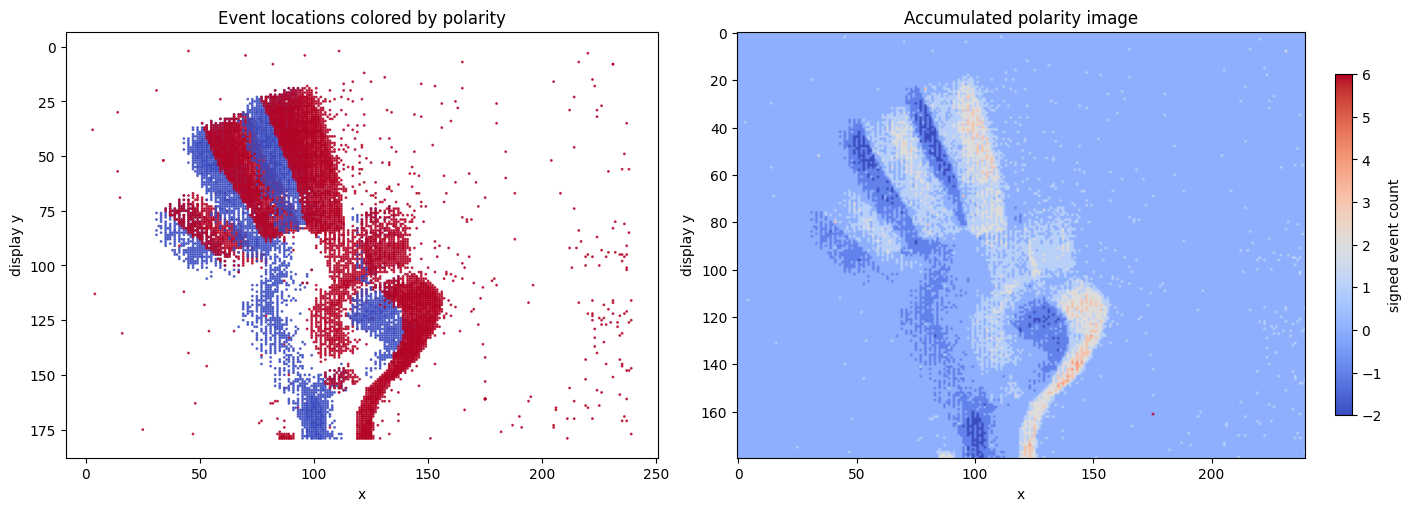

In [ ]:
x = events["x"].astype(np.int64)
raw_y = events["y"].astype(np.int64)
display_y = flip_y_for_display(raw_y)
pol = events["pol"].astype(np.int8)
signed_pol = np.where(pol > 0, 1, -1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].scatter(x, display_y, c=signed_pol, s=1, cmap="coolwarm", alpha=0.8)
axes[0].invert_yaxis()
axes[0].set_title("Event locations colored by polarity")
axes[0].set_xlabel("x")
axes[0].set_ylabel("display y")

accumulated = np.zeros((SENSOR_HEIGHT, SENSOR_WIDTH), dtype=np.int32)
np.add.at(accumulated, (display_y, x), signed_pol)
image = axes[1].imshow(accumulated)
axes[1].set_title("Accumulated polarity image")
axes[1].set_xlabel("x")
axes[1].set_ylabel("display y")
fig.colorbar(image, ax=axes[1], shrink=0.8, label="signed event count")

plt.show()

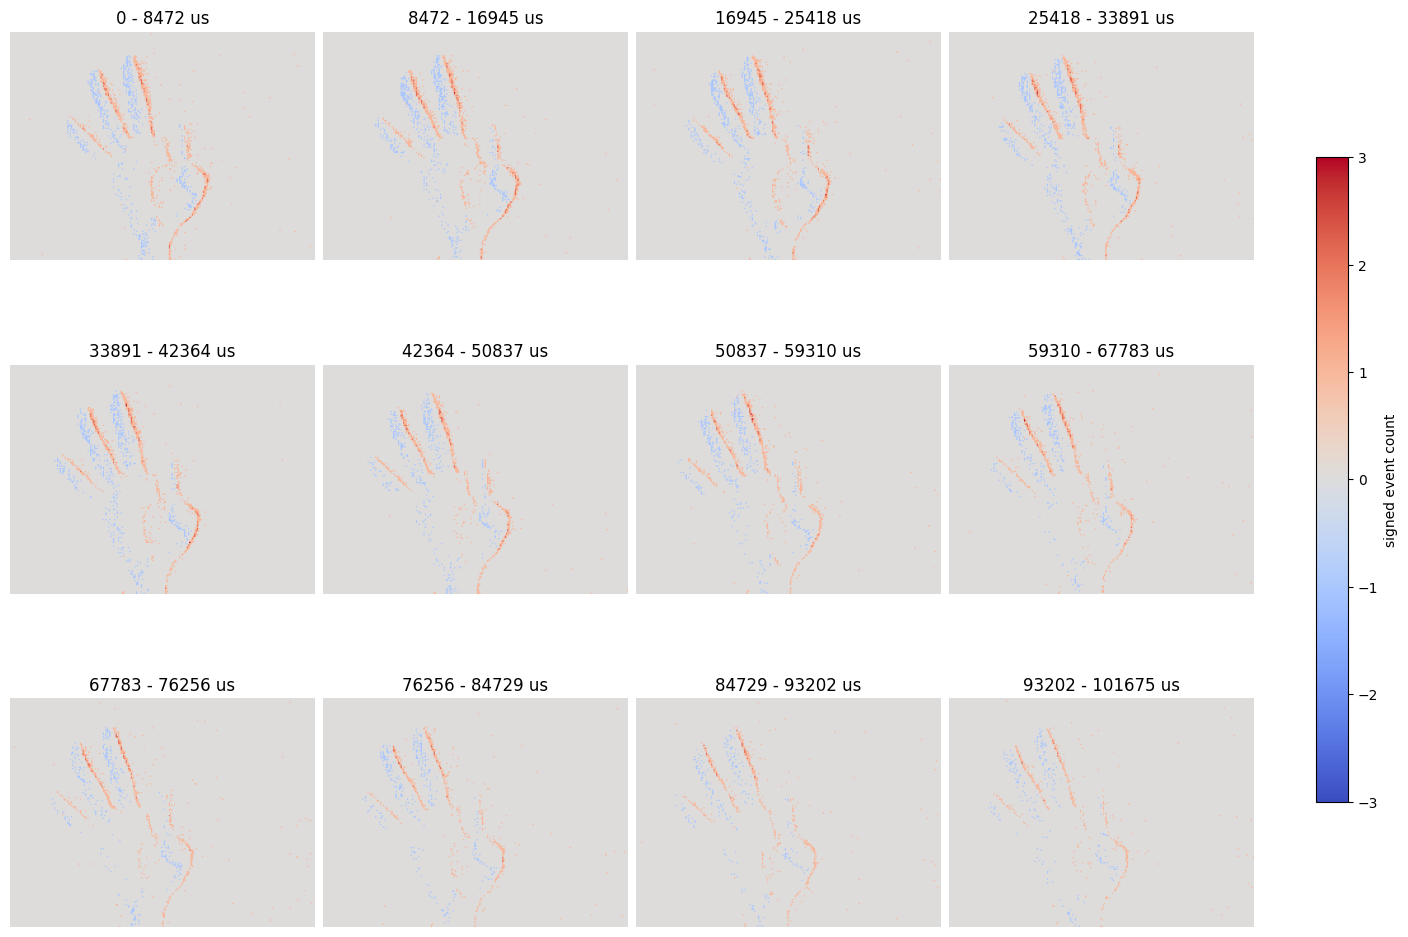

In [ ]:
def make_time_frames(event_dict: dict[str, np.ndarray], n_frames: int = 12):
    x = event_dict["x"].astype(np.int64)
    display_y = flip_y_for_display(event_dict["y"])
    ts = event_dict["ts"].astype(np.int64)
    signed_pol = np.where(event_dict["pol"] > 0, 1, -1).astype(np.int8)

    edges = np.linspace(ts.min(), ts.max() + 1, n_frames + 1, dtype=np.int64)
    frames = np.zeros((n_frames, SENSOR_HEIGHT, SENSOR_WIDTH), dtype=np.int16)

    for frame_idx in range(n_frames):
        mask = (ts >= edges[frame_idx]) & (ts < edges[frame_idx + 1])
        np.add.at(frames[frame_idx], (display_y[mask], x[mask]), signed_pol[mask])

    return frames, edges


frames, frame_edges = make_time_frames(events, n_frames=12)
limit = np.abs(frames).max()

fig, axes = plt.subplots(3, 4, figsize=(14, 10), constrained_layout=True)
for idx, axis in enumerate(axes.flat):
    image = axis.imshow(frames[idx], vmin=-limit, vmax=limit)
    axis.set_title(f"{int(frame_edges[idx])} - {int(frame_edges[idx + 1])} us")
    axis.axis("off")

fig.colorbar(image, ax=axes, shrink=0.65, label="signed event count")
plt.show()

In [ ]:
ANIMATION_FRAMES = 24

anim_frames, anim_edges = make_time_frames(events, n_frames=ANIMATION_FRAMES)
anim_limit = np.abs(anim_frames).max()

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(anim_frames[0], vmin=-anim_limit, vmax=anim_limit)
title = ax.set_title("")
ax.set_xlabel("x")
ax.set_ylabel("display y")


def update(frame_idx: int):
    image.set_data(anim_frames[frame_idx])
    title.set_text(
        f"Frame {frame_idx + 1}/{ANIMATION_FRAMES}: {int(anim_edges[frame_idx])} - {int(anim_edges[frame_idx + 1])} us"
    )
    return image, title


animation = FuncAnimation(fig, update, frames=ANIMATION_FRAMES, interval=180, blit=False)
plt.close(fig)
HTML(animation.to_jshtml())